# Lab Task 3: Face Detection using OpenCV Haar Cascade

**Computer Vision Lab Notebook**

Prepared for Google Colab. Run each cell step by step.

## Lab Task 3: Face Detection using OpenCV Haar Cascade

### Objective
Detect human faces from images using OpenCV Haar Cascade.

### Important Difference
- **Face Detection:** Finds where the face is.
- **Face Recognition:** Identifies whose face it is.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("OpenCV version:", cv2.__version__)

OpenCV version: 4.13.0


## Step 1: Upload One or More Face Images

In [2]:
uploaded = files.upload()
image_paths = list(uploaded.keys())
print("Uploaded files:", image_paths)

Saving apple_pic.png to apple_pic.png
Uploaded files: ['apple_pic.png']


## Step 2: Load Haar Cascade Face Detector

In [3]:
face_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(face_cascade_path)

if face_cascade.empty():
    raise ValueError("Haar Cascade file could not be loaded.")

print("Haar Cascade loaded successfully.")

Haar Cascade loaded successfully.


## Step 3: Create Face Detection Function

In [4]:
def detect_faces(image_path, scaleFactor=1.1, minNeighbors=5):
    img_bgr = cv2.imread(image_path)

    if img_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=scaleFactor,
        minNeighbors=minNeighbors
    )

    output = img_rgb.copy()

    for (x, y, w, h) in faces:
        cv2.rectangle(output, (x, y), (x+w, y+h), (255, 0, 0), 3)

    return img_rgb, gray, output, faces

## Step 4: Run Face Detection on Uploaded Images

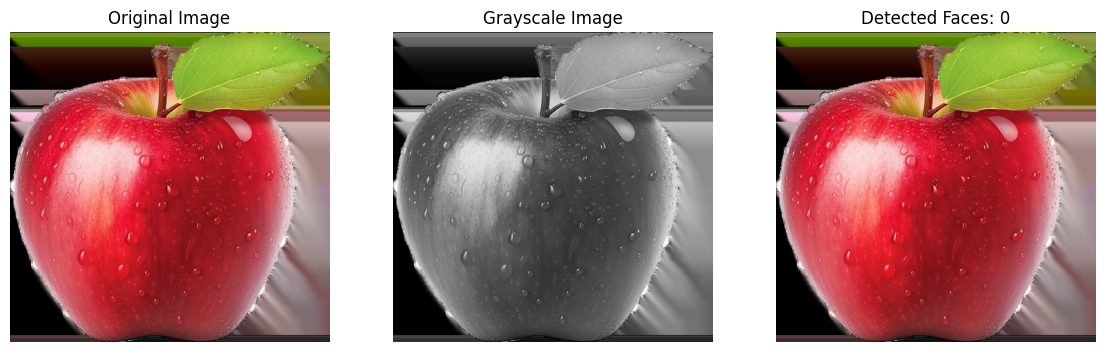

Image: apple_pic.png
Faces detected: 0
----------------------------------------


In [5]:
for image_path in image_paths:
    img_rgb, gray, output, faces = detect_faces(image_path)

    plt.figure(figsize=(14,5))

    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale Image")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(output)
    plt.title(f"Detected Faces: {len(faces)}")
    plt.axis("off")

    plt.show()

    print(f"Image: {image_path}")
    print("Faces detected:", len(faces))
    print("-" * 40)

## Step 5: Try Different Parameters
If faces are not detected properly, try changing `scaleFactor` and `minNeighbors`.

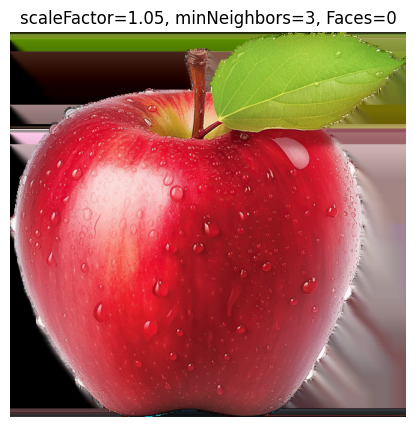

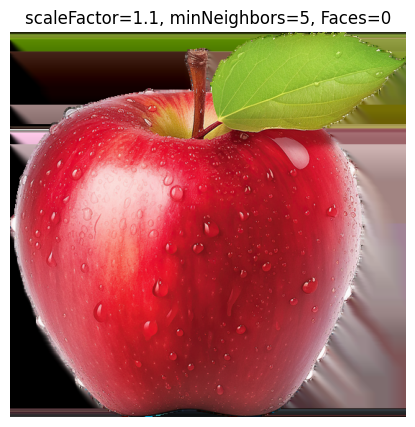

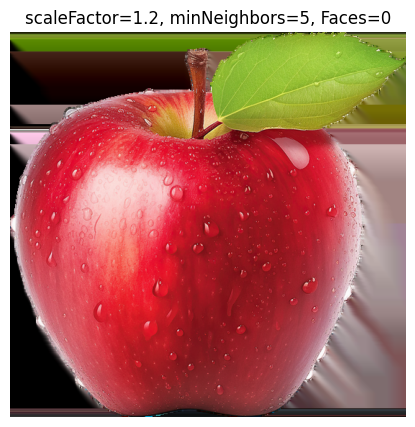

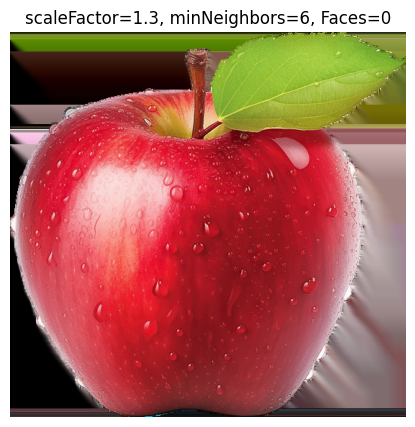

In [6]:
# Select first image for parameter testing
test_image = image_paths[0]

parameter_settings = [
    (1.05, 3),
    (1.1, 5),
    (1.2, 5),
    (1.3, 6)
]

for scaleFactor, minNeighbors in parameter_settings:
    img_rgb, gray, output, faces = detect_faces(
        test_image,
        scaleFactor=scaleFactor,
        minNeighbors=minNeighbors
    )

    plt.figure(figsize=(6,5))
    plt.imshow(output)
    plt.title(f"scaleFactor={scaleFactor}, minNeighbors={minNeighbors}, Faces={len(faces)}")
    plt.axis("off")
    plt.show()

## Optional Bonus: Face Detection on Webcam Video

This part is usually easier on a local Jupyter Notebook or VS Code because Google Colab does not directly support normal webcam OpenCV windows.

Local code example:

```python
import cv2

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x,y), (x+w,y+h), (255,0,0), 2)

    cv2.imshow("Face Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
```

## Student Conclusion

Write your answers:

1. What is face detection?
2. What is the difference between face detection and face recognition?
3. How many faces were detected in each image?
4. What happens when you change `scaleFactor`?
5. What are the limitations of Haar Cascade?